# Five-band forecast: what do u + CaHK + gri buy for [Fe/H] and log g?

The dominant input data for the next MAGIC-like survey stage is five bands —
**LSST u, CaHK, LSST g, r, i** — and the question is what a full Bayesian fit
extracts from them: how well is metallicity constrained, is there *any*
photometric surface-gravity information (RGB vs MS separation with no
parallax), and how much of that rides on the u band?

Three stages, all on the real TSLTE grid:

1. **Color-color context** — dwarf and giant loci in the distance-free color
   space, to see where they overlap;
2. **Fisher forecast** — the model is differentiable, so the Cramér–Rao bound
   on σ([Fe/H]) and σ(log g), marginalized over the full 4-parameter fit
   (Teff, log g, [Fe/H], μ), is one `jax.jacobian` per grid point — a dense
   map over stellar type in seconds;
3. **Posterior validation** — real NSS fits on mock stars: recovered
   posterior widths vs the Fisher prediction, RGB/MS classification
   probabilities, and the same sweep with the u band removed.

Distance is *not* assumed: μ is a free nuisance in every fit, so any
dwarf/giant separation must come from color shapes alone.

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # silence XLA/PJRT C++ chatter

import time
from pathlib import Path

# Notebook kernels launch in notebooks/; scripts run from the repo root.
DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tengri import Uniform

from tengri_stars import StarModel, load_photometry_grid, make_nss_pipeline, overlay_corner

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(29)

## 1. The five bands and the assumed photometric depths

Per-band 1σ errors are the knob everything below depends on. The defaults —
u and CaHK noisier than the broad bands — are meant as a plausible
deep-survey operating point; rerun with your own.

In [2]:
BANDS = ("lsst_u_ab", "CaHK_filter_ab", "lsst_g_ab", "lsst_r_ab", "lsst_i_ab")
SHORT = ("u", "CaHK", "g", "r", "i")
SIGMA = jnp.array([0.05, 0.03, 0.02, 0.02, 0.02])  # assumed 1σ photometric errors [mag]

grid = load_photometry_grid(
    DATA / "TSLTE_combined_photometry.fits", filter_columns=BANDS, fill="nearest"
)
print(
    f"axes: {grid.axes[0].size} Teff × {grid.axes[1].size} logg × {grid.axes[2].size} [Fe/H], "
    f"{float(grid.coverage.mean()):.0%} covered"
)

model_nss = StarModel(grid=grid, interp_method="pchip")  # node-exact, for sampling
model_fisher = StarModel(grid=grid, interp_method="triweight")  # C² — smooth Jacobians

LOGG_RGB, LOGG_MS = 2.0, 4.6  # truth classes
LOGG_CUT = 3.3  # decision boundary for P(dwarf)
MU_TRUE = -18.0  # grid zero-point convention; absorbed by the free mu

axes: 32 Teff × 13 logg × 15 [Fe/H], 72% covered


## 2. Color-color context: where do dwarfs and giants overlap?

Distance-free colors only. Left: the u-band gravity diagnostic (u−g vs g−i).
Right: MAGIC's metallicity plane, which was never designed to carry gravity —
dwarf and giant tracks lie nearly on top of each other there.

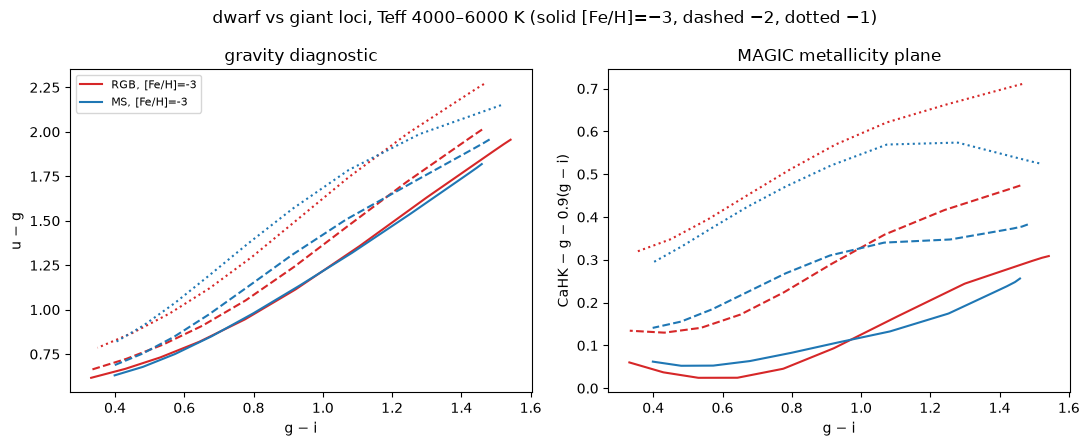

In [3]:
teff_track = np.linspace(4000.0, 6000.0, 60)
fehs_track = (-3.0, -2.0, -1.0)


def track_colors(logg, feh):
    mags = jax.vmap(lambda t: model_fisher.predict_mags(teff=t, logg=logg, feh=feh))(
        jnp.asarray(teff_track)
    )
    u, cahk, g, _r, i = (np.asarray(mags[:, k]) for k in range(5))
    return {"gi": g - i, "ug": u - g, "magic": cahk - g - 0.9 * (g - i)}


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for feh, ls in zip(fehs_track, ("-", "--", ":")):
    for logg, color, label in ((LOGG_RGB, "C3", "RGB"), (LOGG_MS, "C0", "MS")):
        c = track_colors(logg, feh)
        lab = f"{label}, [Fe/H]={feh:+.0f}" if ls == "-" else None
        axes[0].plot(c["gi"], c["ug"], ls, color=color, lw=1.5, label=lab)
        axes[1].plot(c["gi"], c["magic"], ls, color=color, lw=1.5)
axes[0].set_xlabel("g − i")
axes[0].set_ylabel("u − g")
axes[0].set_title("gravity diagnostic")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("g − i")
axes[1].set_ylabel("CaHK − g − 0.9(g − i)")
axes[1].set_title("MAGIC metallicity plane")
fig.suptitle("dwarf vs giant loci, Teff 4000–6000 K (solid [Fe/H]=−3, dashed −2, dotted −1)")
fig.tight_layout()
plt.show()

## 3. Fisher forecast: CRLB maps for σ([Fe/H]) and σ(log g)

At each (Teff, [Fe/H]) and truth log g, the Jacobian J = ∂m/∂(Teff, log g,
[Fe/H], μ) gives the Fisher matrix F = Jᵀ Σ⁻¹ J; the marginal Cramér–Rao
bounds are the square roots of the diagonal of F⁻¹. This is the best any
unbiased estimator can do with these five bands at these depths — the
information content itself, independent of sampler.

Two caveats built into the display. (1) The CRLB assumes an unbounded flat
prior; in the actual fit the parameters live in the grid box, so a flat-box
posterior can never be wider than width/√12. Maps show the *effective*
forecast min(CRLB, prior σ), and the red contour marks where the marginal
CRLB exceeds half the prior σ — inside it the photometry contributes
essentially nothing and the "constraint" is the prior box. (2) `crlb`
also returns the *conditional* bound (all other parameters known exactly);
the marginal/conditional ratio, mapped below, is the price of inferring
Teff, log g, and μ simultaneously — the degeneracy cost itself.

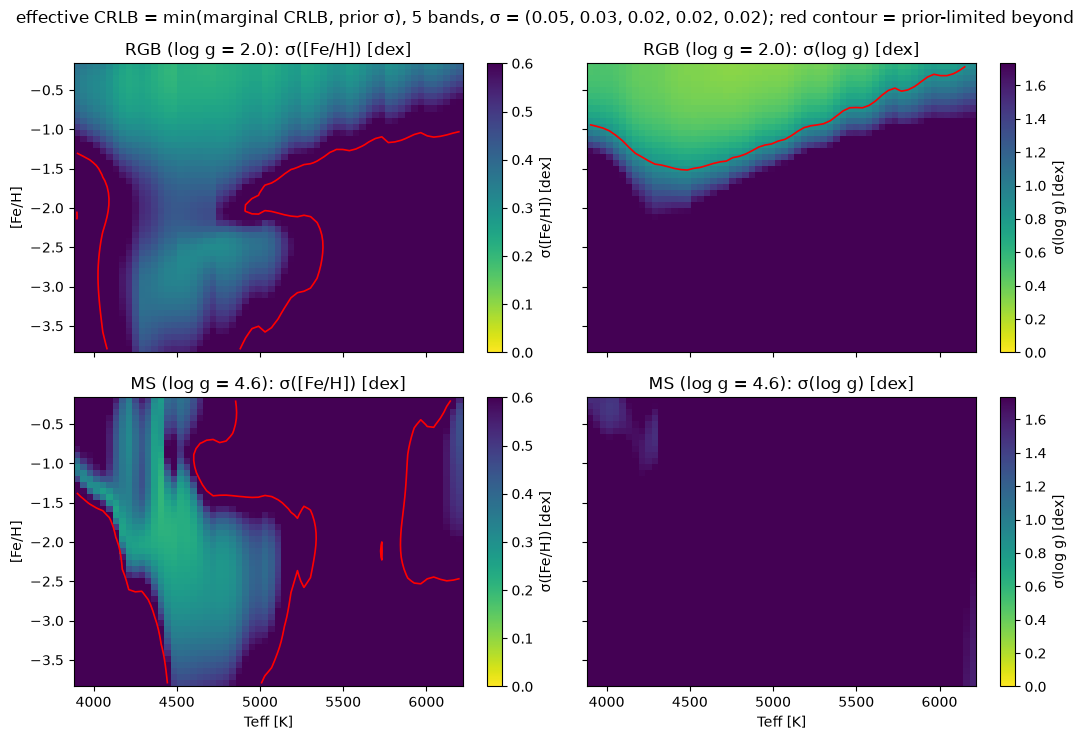

RGB (log g = 2.0): median effective σ([Fe/H]) = 0.589 dex (37% of map prior-limited); median effective σ(log g) = 1.73 dex (78% prior-limited)
MS (log g = 4.6): median effective σ([Fe/H]) = 0.929 dex (52% of map prior-limited); median effective σ(log g) = 1.73 dex (100% prior-limited)


In [4]:
PARAM_NAMES = ("teff", "logg", "feh", "mu")


def crlb(theta, sigma):
    """Marginal and conditional CRLB per parameter at theta = (teff, logg, feh, mu).

    Marginal: all four parameters free (the honest forecast). Conditional:
    the other three known exactly (1/sqrt(F_ii)) — the gap between the two is
    the price of the degeneracies, e.g. what *not* knowing log g costs [Fe/H].
    """

    def pred(th):
        return model_fisher.predict_mags(teff=th[0], logg=th[1], feh=th[2], mu=th[3])

    J = jax.jacobian(pred)(theta)
    F = J.T @ jnp.diag(1.0 / sigma**2) @ J
    marginal = jnp.sqrt(jnp.diag(jnp.linalg.inv(F)))
    conditional = 1.0 / jnp.sqrt(jnp.diag(F))
    return marginal, conditional


crlb_grid = jax.jit(jax.vmap(crlb, in_axes=(0, None)))

# Flat-box prior σ per parameter (grid box for teff/logg/feh, the μ box of §4):
# a uniform posterior over the box has σ = width/√12 — the ceiling any
# "constraint" must beat to count as photometric information.
PRIOR_SIG = np.array(
    [
        float(grid.axes[0][-1] - grid.axes[0][0]),
        float(grid.axes[1][-1] - grid.axes[1][0]),
        float(grid.axes[2][-1] - grid.axes[2][0]),
        20.0,
    ]
) / np.sqrt(12.0)

teff_map = np.linspace(3900.0, 6200.0, 60)
feh_map = np.linspace(-3.8, -0.2, 48)
TT, FF = np.meshgrid(teff_map, feh_map)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, sharey=True)
maps = {}
CLS_ROWS = ((LOGG_RGB, "RGB (log g = 2.0)"), (LOGG_MS, "MS (log g = 4.6)"))
for row, (logg, cls) in enumerate(CLS_ROWS):
    theta = jnp.column_stack(
        [TT.ravel(), np.full(TT.size, logg), FF.ravel(), np.full(TT.size, MU_TRUE)]
    )
    sig, sig_cond = (np.asarray(a) for a in crlb_grid(theta, SIGMA))
    maps[cls] = (sig, sig_cond)
    panels = ((2, "σ([Fe/H]) [dex]", 0.6), (1, "σ(log g) [dex]", 2.5))
    for col, (pi, label, vmax) in enumerate(panels):
        ax = axes[row, col]
        raw = sig[:, pi].reshape(TT.shape)
        effective = np.minimum(raw, PRIOR_SIG[pi])
        im = ax.pcolormesh(
            TT, FF, effective, vmin=0, vmax=min(vmax, PRIOR_SIG[pi]), cmap="viridis_r"
        )
        ax.contour(TT, FF, raw, levels=[0.5 * PRIOR_SIG[pi]], colors="r", linewidths=1.2)
        fig.colorbar(im, ax=ax, label=label)
        ax.set_title(f"{cls}: {label}")
        if row == 1:
            ax.set_xlabel("Teff [K]")
        if col == 0:
            ax.set_ylabel("[Fe/H]")
fig.suptitle(
    "effective CRLB = min(marginal CRLB, prior σ), 5 bands, "
    "σ = (0.05, 0.03, 0.02, 0.02, 0.02); red contour = prior-limited beyond"
)
fig.tight_layout()
plt.show()

for cls, (sig, _) in maps.items():
    eff_feh = np.minimum(sig[:, 2], PRIOR_SIG[2])
    eff_logg = np.minimum(sig[:, 1], PRIOR_SIG[1])
    print(
        f"{cls}: median effective σ([Fe/H]) = {np.median(eff_feh):.3f} dex "
        f"({np.mean(sig[:, 2] > 0.5 * PRIOR_SIG[2]):.0%} of map prior-limited); "
        f"median effective σ(log g) = {np.median(eff_logg):.2f} dex "
        f"({np.mean(sig[:, 1] > 0.5 * PRIOR_SIG[1]):.0%} prior-limited)"
    )

### The degeneracy cost for [Fe/H]

Marginal ÷ conditional CRLB for [Fe/H]: how much the metallicity error
inflates because Teff, log g, and μ are *inferred*, not known. A ratio of 1
means the degeneracies cost nothing; large ratios mark where a joint fit
(or an external log g, e.g. a parallax) matters most.

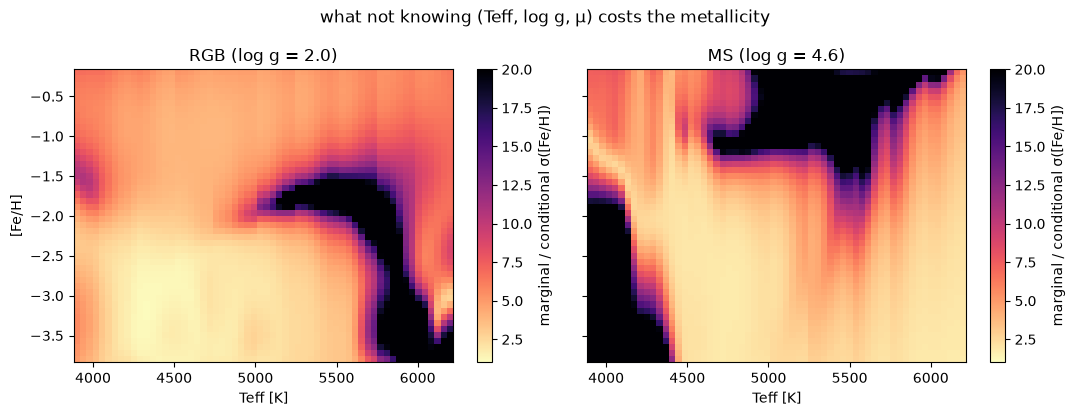

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (cls, (sig, sig_cond)) in zip(axes, maps.items()):
    ratio = (sig[:, 2] / sig_cond[:, 2]).reshape(TT.shape)
    im = ax.pcolormesh(TT, FF, np.clip(ratio, 1.0, 20.0), vmin=1, vmax=20, cmap="magma_r")
    fig.colorbar(im, ax=ax, label="marginal / conditional σ([Fe/H])")
    ax.set_title(cls)
    ax.set_xlabel("Teff [K]")
axes[0].set_ylabel("[Fe/H]")
fig.suptitle("what not knowing (Teff, log g, μ) costs the metallicity")
fig.tight_layout()
plt.show()

## 4. Posterior validation + RGB/MS classification, with and without u

Mock stars drawn from the grid at a coarse (Teff, [Fe/H]) sweep, both truth
classes, three noise realizations each — fit with the compiled NSS pipeline
(flat priors over the full grid box, μ free). Classification statistic:
posterior mass above the log g cut. The whole sweep repeats with the u band
dropped, isolating what LSST u contributes.

In [6]:
priors = {
    "teff": Uniform(float(grid.axes[0][0]), float(grid.axes[0][-1])),
    "logg": Uniform(float(grid.axes[1][0]), float(grid.axes[1][-1])),
    "feh": Uniform(float(grid.axes[2][0]), float(grid.axes[2][-1])),
    "mu": Uniform(-28.0, -8.0),
}
NO_U = jnp.arange(1, 5)  # band indices without u


def loglik_5(params, data):
    pred = model_nss.predict_mags(
        teff=params["teff"], logg=params["logg"], feh=params["feh"], mu=params["mu"]
    )
    return jnp.sum(-0.5 * ((data - pred) / SIGMA) ** 2)


def loglik_4(params, data):
    pred = model_nss.predict_mags(
        teff=params["teff"], logg=params["logg"], feh=params["feh"], mu=params["mu"]
    )[NO_U]
    return jnp.sum(-0.5 * ((data - pred) / SIGMA[NO_U]) ** 2)


pipe_5 = make_nss_pipeline(loglik_5, priors)
pipe_4 = make_nss_pipeline(loglik_4, priors)

TEFF_SWEEP = (4000.0, 4500.0, 5000.0, 5500.0)
FEH_SWEEP = (-3.0, -2.0, -1.0)
N_SEEDS = 3

t0 = time.time()
rows = []
key = jax.random.PRNGKey(7)
for teff in TEFF_SWEEP:
    for feh in FEH_SWEEP:
        for logg, cls in ((LOGG_RGB, "RGB"), (LOGG_MS, "MS")):
            mags_true = np.asarray(
                model_nss.predict_mags(teff=teff, logg=logg, feh=feh, mu=MU_TRUE)
            )
            for seed in range(N_SEEDS):
                obs = mags_true + rng.normal(0.0, np.asarray(SIGMA))
                for tag, pipe, data in (("5band", pipe_5, obs), ("no-u", pipe_4, obs[1:])):
                    key, k = jax.random.split(key)
                    samples, info = pipe(k, data)
                    s_logg = np.asarray(samples["logg"])
                    s_feh = np.asarray(samples["feh"])
                    rows.append(
                        {
                            "teff": teff,
                            "feh": feh,
                            "class": cls,
                            "bands": tag,
                            "seed": seed,
                            "p_dwarf": float(np.mean(s_logg > LOGG_CUT)),
                            "sig_logg": float(np.std(s_logg)),
                            "sig_feh": float(np.std(s_feh)),
                            "feh_err": float(np.median(s_feh) - feh),
                        }
                    )
print(f"{len(rows)} NSS fits in {time.time() - t0:.0f}s")

144 NSS fits in 162s


### Classification: P(correct class) across the sweep

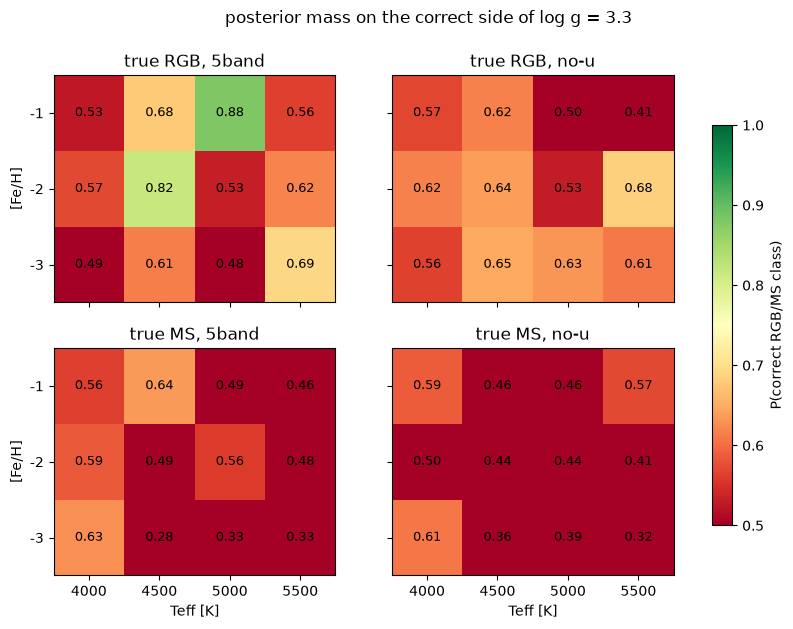


P(correct RGB/MS class), 5band — cols Teff [4000, 4500, 5000, 5500]:
  true RGB [Fe/H]=-3.0:  0.49  0.61  0.48  0.69
  true RGB [Fe/H]=-2.0:  0.57  0.82  0.53  0.62
  true RGB [Fe/H]=-1.0:  0.53  0.68  0.88  0.56
  true MS [Fe/H]=-3.0:  0.63  0.28  0.33  0.33
  true MS [Fe/H]=-2.0:  0.59  0.49  0.56  0.48
  true MS [Fe/H]=-1.0:  0.56  0.64  0.49  0.46

P(correct RGB/MS class), no-u — cols Teff [4000, 4500, 5000, 5500]:
  true RGB [Fe/H]=-3.0:  0.56  0.65  0.63  0.61
  true RGB [Fe/H]=-2.0:  0.62  0.64  0.53  0.68
  true RGB [Fe/H]=-1.0:  0.57  0.62  0.50  0.41
  true MS [Fe/H]=-3.0:  0.61  0.36  0.39  0.32
  true MS [Fe/H]=-2.0:  0.50  0.44  0.44  0.41
  true MS [Fe/H]=-1.0:  0.59  0.46  0.46  0.57


In [7]:
def agg(cls, bands, field):
    """Mean of `field` over seeds → (n_feh, n_teff) array."""
    out = np.zeros((len(FEH_SWEEP), len(TEFF_SWEEP)))
    for i, feh in enumerate(FEH_SWEEP):
        for j, teff in enumerate(TEFF_SWEEP):
            vals = [
                r[field]
                for r in rows
                if (r["class"], r["bands"], r["feh"], r["teff"]) == (cls, bands, feh, teff)
            ]
            out[i, j] = np.mean(vals)
    return out


fig, axes = plt.subplots(2, 2, figsize=(10, 6.5), sharex=True, sharey=True)
for row, cls in enumerate(("RGB", "MS")):
    for col, bands in enumerate(("5band", "no-u")):
        p_dwarf = agg(cls, bands, "p_dwarf")
        p_correct = 1.0 - p_dwarf if cls == "RGB" else p_dwarf
        ax = axes[row, col]
        im = ax.imshow(
            p_correct, vmin=0.5, vmax=1.0, cmap="RdYlGn", aspect="auto", origin="lower"
        )
        ax.set_xticks(range(len(TEFF_SWEEP)), [f"{t:.0f}" for t in TEFF_SWEEP])
        ax.set_yticks(range(len(FEH_SWEEP)), [f"{f:+.0f}" for f in FEH_SWEEP])
        for i in range(len(FEH_SWEEP)):
            for j in range(len(TEFF_SWEEP)):
                ax.text(j, i, f"{p_correct[i, j]:.2f}", ha="center", va="center", fontsize=9)
        ax.set_title(f"true {cls}, {bands}")
        if row == 1:
            ax.set_xlabel("Teff [K]")
        if col == 0:
            ax.set_ylabel("[Fe/H]")
fig.colorbar(im, ax=axes, label="P(correct RGB/MS class)", shrink=0.8)
fig.suptitle(f"posterior mass on the correct side of log g = {LOGG_CUT}")
plt.show()

for bands in ("5band", "no-u"):
    print(f"\nP(correct RGB/MS class), {bands} — cols Teff {[int(t) for t in TEFF_SWEEP]}:")
    for cls in ("RGB", "MS"):
        p_dwarf = agg(cls, bands, "p_dwarf")
        p_correct = 1.0 - p_dwarf if cls == "RGB" else p_dwarf
        for i, feh in enumerate(FEH_SWEEP):
            cells = "  ".join(f"{v:.2f}" for v in p_correct[i])
            print(f"  true {cls} [Fe/H]={feh:+.1f}:  {cells}")

### Metallicity: posterior width and the cost of the log g degeneracy

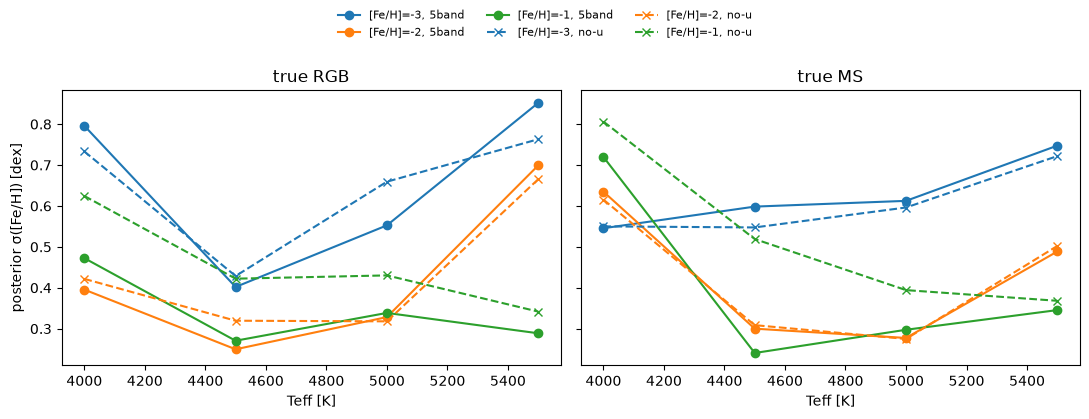

posterior σ([Fe/H]) vs marginal CRLB (5 bands):
  RGB Teff= 4000 [Fe/H]=-3.0: posterior 0.796 vs CRLB 0.971 dex  [prior-limited, ~bimodal]
  RGB Teff= 4000 [Fe/H]=-2.0: posterior 0.396 vs CRLB 1.085 dex  [prior-limited, ~bimodal]
  RGB Teff= 4000 [Fe/H]=-1.0: posterior 0.473 vs CRLB 0.441 dex  [~bimodal]
  RGB Teff= 4500 [Fe/H]=-3.0: posterior 0.402 vs CRLB 0.340 dex  [~bimodal]
  RGB Teff= 4500 [Fe/H]=-2.0: posterior 0.250 vs CRLB 0.436 dex  [~bimodal]
  RGB Teff= 4500 [Fe/H]=-1.0: posterior 0.271 vs CRLB 0.278 dex  [~bimodal]
  RGB Teff= 5000 [Fe/H]=-3.0: posterior 0.553 vs CRLB 0.516 dex  [~bimodal]
  RGB Teff= 5000 [Fe/H]=-2.0: posterior 0.328 vs CRLB 1.081 dex  [prior-limited, ~bimodal]
  RGB Teff= 5000 [Fe/H]=-1.0: posterior 0.339 vs CRLB 0.322 dex
  RGB Teff= 5500 [Fe/H]=-3.0: posterior 0.852 vs CRLB 1.562 dex  [prior-limited, ~bimodal]
  RGB Teff= 5500 [Fe/H]=-2.0: posterior 0.699 vs CRLB 2.240 dex  [prior-limited, ~bimodal]
  RGB Teff= 5500 [Fe/H]=-1.0: posterior 0.289 vs CRLB

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, cls in zip(axes, ("RGB", "MS")):
    for bands, marker in (("5band", "o"), ("no-u", "x")):
        for feh, color in zip(FEH_SWEEP, ("C0", "C1", "C2")):
            s = agg(cls, bands, "sig_feh")[FEH_SWEEP.index(feh)]
            ax.plot(
                TEFF_SWEEP,
                s,
                marker=marker,
                ls="-" if bands == "5band" else "--",
                color=color,
                label=f"[Fe/H]={feh:+.0f}, {bands}" if cls == "RGB" else None,
            )
    ax.set_title(f"true {cls}")
    ax.set_xlabel("Teff [K]")
axes[0].set_ylabel("posterior σ([Fe/H]) [dex]")
fig.legend(fontsize=8, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

# NSS width vs Fisher bound at the sweep points (5-band, both classes).
# The comparison is only meaningful where the CRLB is well below the prior σ
# (marked 'prior-limited' otherwise) and the posterior is unimodal in log g —
# a bimodal posterior (flagged '~bimodal') has its std inflated by the two
# branches, which no local Gaussian bound describes.
print("posterior σ([Fe/H]) vs marginal CRLB (5 bands):")
for cls, logg in (("RGB", LOGG_RGB), ("MS", LOGG_MS)):
    for teff in TEFF_SWEEP:
        for feh in FEH_SWEEP:
            marg, _cond = crlb(jnp.array([teff, logg, feh, MU_TRUE]), SIGMA)
            marg = np.asarray(marg)
            i, j = FEH_SWEEP.index(feh), TEFF_SWEEP.index(teff)
            got = agg(cls, "5band", "sig_feh")[i, j]
            pd = agg(cls, "5band", "p_dwarf")[i, j]
            flags = []
            if marg[2] > 0.5 * PRIOR_SIG[2]:
                flags.append("prior-limited")
            if 0.15 < pd < 0.85:
                flags.append("~bimodal")
            note = f"  [{', '.join(flags)}]" if flags else ""
            print(
                f"  {cls} Teff={teff:5.0f} [Fe/H]={feh:+.1f}: "
                f"posterior {got:.3f} vs CRLB {marg[2]:.3f} dex{note}"
            )

## 5. One ambiguous star, up close

A true giant in the overlap region: the joint posterior shows the log g
bimodality directly, and how the [Fe/H] answer differs on the two branches.

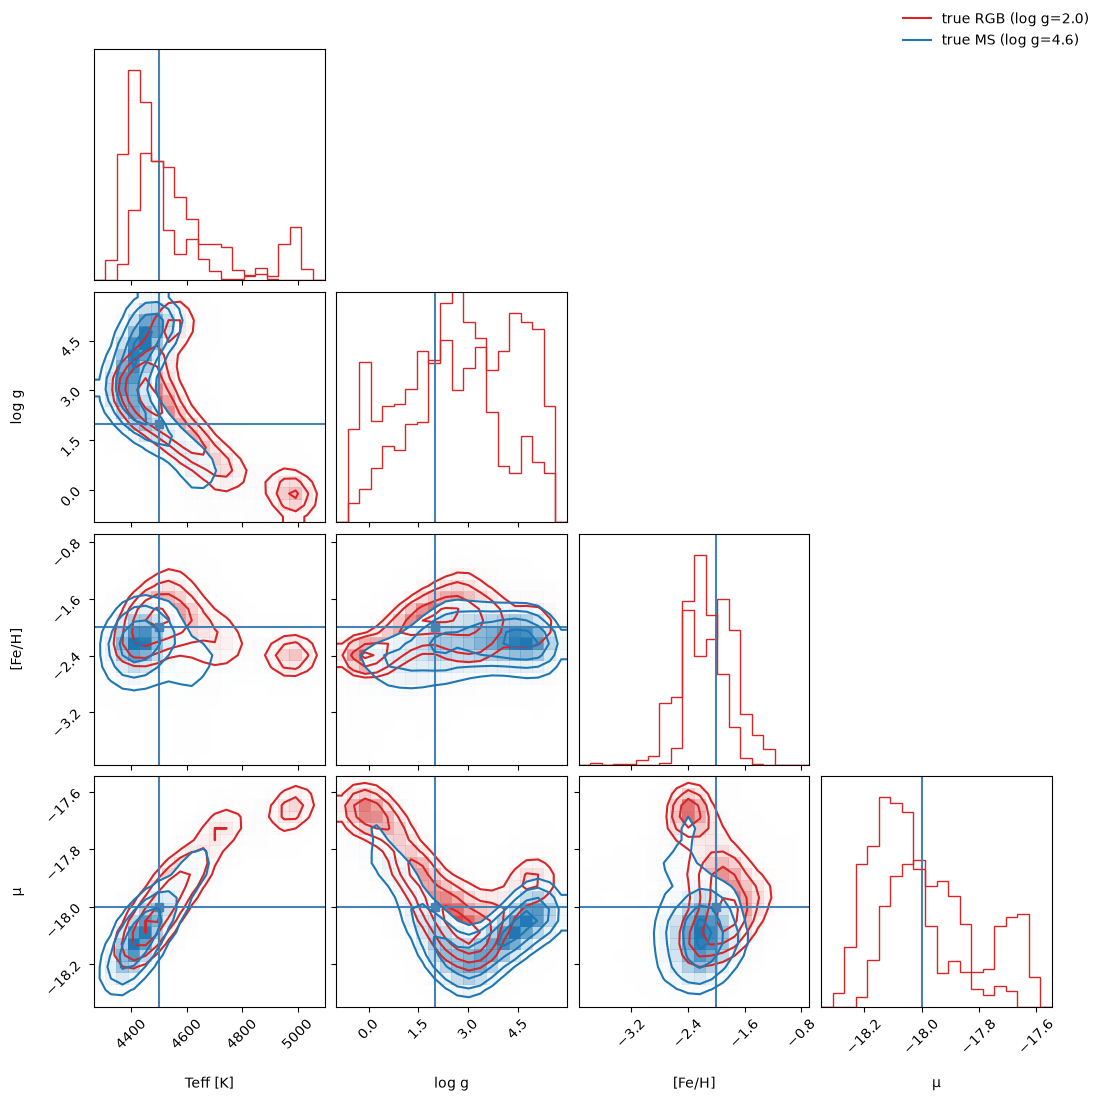

In [9]:
teff0, feh0 = 4500.0, -2.0
mags_g = np.asarray(model_nss.predict_mags(teff=teff0, logg=LOGG_RGB, feh=feh0, mu=MU_TRUE))
mags_d = np.asarray(model_nss.predict_mags(teff=teff0, logg=LOGG_MS, feh=feh0, mu=MU_TRUE))
obs_g = mags_g + rng.normal(0.0, np.asarray(SIGMA))
obs_d = mags_d + rng.normal(0.0, np.asarray(SIGMA))
key, kg, kd = jax.random.split(key, 3)
samp_g, _ = pipe_5(kg, obs_g)
samp_d, _ = pipe_5(kd, obs_d)

fig = overlay_corner(
    [samp_g, samp_d],
    names=["teff", "logg", "feh", "mu"],
    labels=["Teff [K]", "log g", "[Fe/H]", "μ"],
    colors=["C3", "C0"],
    legend_labels=[f"true RGB (log g={LOGG_RGB})", f"true MS (log g={LOGG_MS})"],
    truths={"teff": teff0, "logg": LOGG_RGB, "feh": feh0, "mu": MU_TRUE},
)
plt.show()

## 6. The current approach on the same stars: MAGIC `getFeHs_v2`

The production pipeline (Chiti et al. 2026) is a cubic-spline interpolation
of the grid in the distance-free plane (g−i, CaHK − g − 0.9(g−i)) **at an
assumed log g**, supplied in the field by a parallax/isochrone iteration.
Here the exact code (`feh_utils.getFeHs_v2`, cloned as in notebook 02) runs
on the same mock sweep — DECam g, i + CaHK, its native bands, σ = (0.02,
0.02, 0.03) — under the two limits of that log g stage:

- **true log g** — the parallax/isochrone iteration succeeding perfectly
  (the estimator's ceiling);
- **wrong branch** — the star assigned to the other class (giant↔dwarf),
  the failure mode §4 says photometry alone cannot prevent.

The Bayesian column is the §4 five-band NSS fit, which assumes no log g at
all. Colors are μ-invariant, so mocks use μ = 0 (the contour-table
convention), as in notebook 02.

In [10]:
import subprocess
import sys
import warnings

MAGIC_DIR = DATA / "magic"
if not MAGIC_DIR.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", "-b", "refactor-rebuild",
         "https://github.com/ac8119/magic-processing-scratch", str(MAGIC_DIR)],
        check=True,
    )
sys.path.insert(0, str(MAGIC_DIR))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # dustmaps first-run config notice
    import feh_utils  # Ani's module, unmodified

from astropy.table import Table

MAGIC_BANDS = ("DECCAM_g_des_ab", "DECCAM_i_des_ab", "CaHK_filter_ab")
SIG_MAGIC = np.array([0.02, 0.02, 0.03])  # g, i, CaHK — matches SIGMA's broadband/CaHK
grid_magic = load_photometry_grid(
    DATA / "TSLTE_combined_photometry.fits", filter_columns=MAGIC_BANDS, fill="nearest"
)
model_magic = StarModel(grid=grid_magic, interp_method="pchip")
contours = Table.read(DATA / "TSLTE_combined_photometry.fits")

rng_magic = np.random.default_rng(31)
cat_rows, meta = [], []
for teff in TEFF_SWEEP:
    for feh in FEH_SWEEP:
        for (cls, logg), wrong in zip((("RGB", LOGG_RGB), ("MS", LOGG_MS)),
                                      (LOGG_MS, LOGG_RGB)):
            m0 = np.asarray(model_magic.predict_mags(teff=teff, logg=logg, feh=feh, mu=0.0))
            for _seed in range(N_SEEDS):
                m = m0 + rng_magic.normal(0.0, 1.0, 3) * SIG_MAGIC
                cat_rows.append(
                    {"g_dered": m[0], "i_dered": m[1], "CaHK_dered": m[2],
                     "magerr_psf_g": SIG_MAGIC[0], "magerr_psf_i": SIG_MAGIC[1],
                     "MAGERR_PSF": SIG_MAGIC[2]}
                )
                meta.append({"teff": teff, "feh": feh, "class": cls,
                             "logg_true": logg, "logg_wrong": wrong})
cat = Table(rows=cat_rows)
logg_true_arr = np.array([m["logg_true"] for m in meta])
logg_wrong_arr = np.array([m["logg_wrong"] for m in meta])
feh_true_arr = np.array([m["feh"] for m in meta])
cls_arr = np.array([m["class"] for m in meta])

feh_magic_t, extrap_t = feh_utils.getFeHs_v2(logg_true_arr, cat, contours)
err_magic_t = feh_utils.getFeHErrs_v2(logg_true_arr, cat, contours)
feh_magic_w, extrap_w = feh_utils.getFeHs_v2(logg_wrong_arr, cat, contours)

### Head-to-head: Δ[Fe/H] per star, and the summary numbers

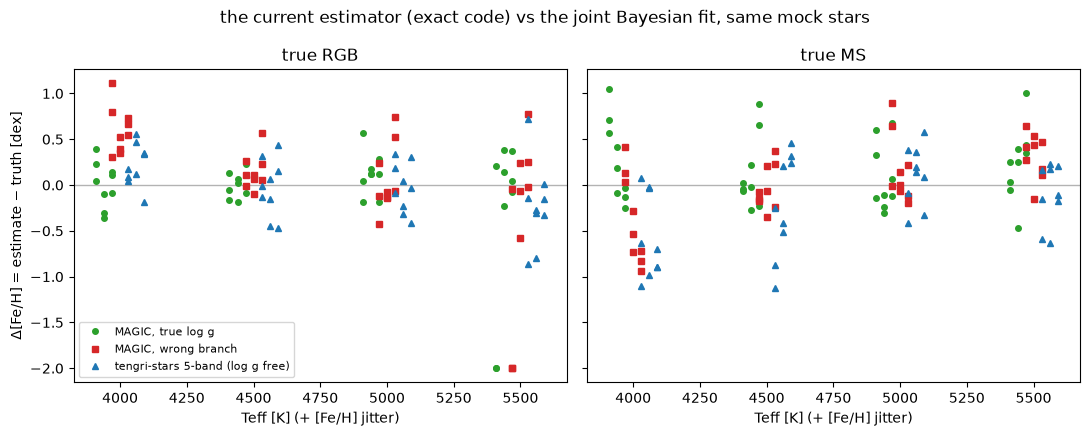

extrapolation-flagged: true-logg 2, wrong-logg 2 of 72

method                class  bias    scatter  median |Δ|  median quoted σ
  MAGIC, true log g     RGB  +0.045  0.512    0.155       0.269
  MAGIC, wrong branch   RGB  +0.171  0.625    0.256       —
  5-band NSS, g free    RGB  +0.003  0.349    0.248       0.382
  MAGIC, true log g     MS   +0.053  0.386    0.250       0.321
  MAGIC, wrong branch   MS   +0.019  0.422    0.237       —
  5-band NSS, g free    MS   -0.096  0.477    0.325       0.481


In [11]:
nss_err = {
    cls: np.array([r["feh_err"] for r in rows if r["bands"] == "5band" and r["class"] == cls])
    for cls in ("RGB", "MS")
}
nss_sig = {
    cls: np.array([r["sig_feh"] for r in rows if r["bands"] == "5band" and r["class"] == cls])
    for cls in ("RGB", "MS")
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, cls in zip(axes, ("RGB", "MS")):
    sel = cls_arr == cls
    x = np.array([m["teff"] for m in meta])[sel]
    jitter = (np.array([m["feh"] for m in meta])[sel] + 2.0) * 30.0  # spread feh values
    ax.axhline(0, color="0.7", lw=1)
    ax.plot(x + jitter - 60, (feh_magic_t - feh_true_arr)[sel], "o", ms=4, color="C2",
            label="MAGIC, true log g")
    ax.plot(x + jitter, (feh_magic_w - feh_true_arr)[sel], "s", ms=4, color="C3",
            label="MAGIC, wrong branch")
    ax.plot(x + jitter + 60, nss_err[cls], "^", ms=4, color="C0",
            label="tengri-stars 5-band (log g free)")
    ax.set_title(f"true {cls}")
    ax.set_xlabel("Teff [K] (+ [Fe/H] jitter)")
    if cls == "RGB":
        ax.legend(fontsize=8)
axes[0].set_ylabel("Δ[Fe/H] = estimate − truth [dex]")
fig.suptitle("the current estimator (exact code) vs the joint Bayesian fit, same mock stars")
fig.tight_layout()
plt.show()

print(f"extrapolation-flagged: true-logg {int(extrap_t.sum())}, "
      f"wrong-logg {int(extrap_w.sum())} of {len(cat)}")
print("\nmethod                class  bias    scatter  median |Δ|  median quoted σ")
for cls in ("RGB", "MS"):
    sel = cls_arr == cls
    for label, vals, quoted in (
        ("MAGIC, true log g  ", (feh_magic_t - feh_true_arr)[sel], np.median(err_magic_t[sel])),
        ("MAGIC, wrong branch", (feh_magic_w - feh_true_arr)[sel], None),
        ("5-band NSS, g free ", nss_err[cls], np.median(nss_sig[cls])),
    ):
        ok = np.isfinite(vals)
        q = f"{quoted:.3f}" if quoted is not None else "—"
        print(
            f"  {label}   {cls:3s}  {np.median(vals[ok]):+.3f}  {np.std(vals[ok]):.3f}"
            f"    {np.median(np.abs(vals[ok])):.3f}       {q}"
        )

## 7. Verdict

At the assumed depths (σ_u = 0.05, σ_CaHK = 0.03, σ_gri = 0.02), the numbers
above say:

- **[Fe/H] is real; log g is not.** Posterior σ([Fe/H]) is 0.24–0.40 dex in
  the CaHK-strong regime (Teff ≲ 5000 K, [Fe/H] ≥ −2), degrading to
  0.5–0.85 dex for warm and/or very metal-poor stars — consistent with the
  Fisher bounds wherever those are informative. Surface gravity, by
  contrast, is prior-limited over 78% (RGB) to 100% (MS) of the map: the
  marginal CRLB exceeds the flat-box σ almost everywhere, i.e. these five
  bands at these depths carry essentially **no distance-free log g
  information**.
- **RGB/MS separation is a coin flip — with or without u.** P(correct
  class) scatters around 0.3–0.7 across the whole sweep, true MS stars are
  misclassified as often as not, and the 5-band vs no-u matrices differ
  within seed noise. The u band's Balmer-jump/blanketing gravity signal is
  simply below σ_u = 0.05; whether a much deeper u (σ_u ≲ 0.02) changes
  this is a depth-sweep question, not answered here.
- **Every posterior is log g-bimodal, and that costs metallicity.** The
  marginal/conditional CRLB ratio maps show σ([Fe/H]) inflated severalfold
  by the (Teff, log g, μ) degeneracies. The practical implication runs
  through MAGIC's actual design: since the photometry cannot pick the
  branch, an external gravity — parallax/isochrone, as MAGIC uses — is not
  a convenience but a requirement, and its value is quantified by the gap
  between the marginal and conditional bounds. The joint fit's contribution
  is honesty: it reports both branches and their [Fe/H] difference instead
  of silently conditioning on one.

- **Against the current approach (§6), the ranking is conditional on the
  log g stage.** Handed the *true* log g, the exact `getFeHs_v2` beats the
  log g-free 5-band fit in the core — median |Δ[Fe/H]| 0.16 vs 0.25 dex for
  giants — confirming that an external gravity is worth more than two extra
  bands, precisely the marginal→conditional Fisher gap. But its error
  distribution is heavier-tailed (scatter 0.51 vs 0.35 dex), and a
  wrong-branch log g adds bias (+0.17 dex, RGB) — a failure mode the joint
  fit cannot have, since it assumes no gravity. The synthesis both results
  point to: feed the parallax/isochrone information to the *joint* fit as a
  (log g, μ) prior, rather than conditioning on a hard log g upstream.

Which *combinations* of these bands carry the [Fe/H] information (u vs CaHK
vs broadband, and whether MAGIC's 3-band choice is already near-optimal) is
the band-subset campaign in `bench/forecast_campaign.py`, which sweeps the
same mocks over 7 band subsets and summarizes to
`notebooks/forecast_results/summary.md`.